# 3. Isochrone Computation & Analysis

Run 1_preprocessing once before this notebook.

## 1. Setup

In [ ]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sys
from isochrones import compute_isochrones_for_points, load_isochrones, save_isochrones

PRE_DIR = f'./data/preprocessed'
ISO_DIR = f'./data/preprocessed/isochrones'
FIG_DIR = f'./figures'
os.makedirs(ISO_DIR, exist_ok=True)

# personal Chiara Genuardi token
# ORS_API_KEY = 'eyJvcmciOiI1YjNjZTM1OTc4NTUxMTAwMDFjZjYyNDgiLCJpZCI6ImIwNjRmMjQyYzViNjQzZWI4NDAyODdmMWYxNjVmNWM2IiwiaCI6Im11cm11cjY0In0='

# personal Camilla Gentili token
ORS_API_KEY = 'eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjcyMWQxZDIyNjZmNzQzN2Q5NmIwNjExZDk3ZjZhMzgzIiwiaCI6Im11cm11cjY0In0='

TRIP_TIMES = [5, 10, 15]

COLOR_MAP = {
    15: ('#f4a582', 0.35),
    10: ('#d6604d', 0.50),
     5: ('#a50026', 0.70),
}

## 2. Load preprocessed data

In [3]:
border           = gpd.read_file(f'{PRE_DIR}/milano_border.geojson')
municipalities   = gpd.read_file(f'{PRE_DIR}/milano_municipalities.geojson')
nil              = gpd.read_file(f'{PRE_DIR}/milano_nil.geojson')

roads            = gpd.read_file(f'{PRE_DIR}/milano_roads.geojson')
squares          = gpd.read_file(f'{PRE_DIR}/milano_squares.geojson')

education        = gpd.read_file(f'{PRE_DIR}/milano_education.geojson')
food_drink       = gpd.read_file(f'{PRE_DIR}/milano_food_drink.geojson')
healthcare       = gpd.read_file(f'{PRE_DIR}/milano_healthcare.geojson')
places_overture_all = gpd.read_file(f'{PRE_DIR}/milano_places_all.geojson')
shops            = gpd.read_file(f'{PRE_DIR}/milano_shops.geojson')
transit_stations = gpd.read_file(f'{PRE_DIR}/milano_transit_stations.geojson')
green_areas      = gpd.read_file(f'{PRE_DIR}/milano_green_areas.geojson')

points_piazze    = gpd.read_file(f'{PRE_DIR}/piazze_aperte.geojson')

nil_anagrafica   = pd.read_csv(f'{PRE_DIR}/nil_anagrafica.csv')
nil_2024         = pd.read_csv(f'{PRE_DIR}/nil_2024.csv')
nil_2025         = pd.read_csv(f'{PRE_DIR}/nil_2025.csv')
nil_full         = pd.read_csv(f'{PRE_DIR}/nil_full.csv')

print(f'Piazze Aperte: {len(points_piazze)} points')

Piazze Aperte: 132 points


## 3. Compute & save isochrones

Run this section only once. Then you can directly go to section 4.

In [4]:
results = compute_isochrones_for_points(
    points_gdf=points_piazze,
    api_key=ORS_API_KEY,
    trip_times=TRIP_TIMES,
    id_column='piazza_id',
    output_dir=ISO_DIR,
    output_prefix='piazze_aperte',
    smoothing=0.5,
)
print('Done.')

Sending 27 requests to ORS for 132 points (5 locations/request)...
  [5/132] done (batch 1/27)
  [10/132] done (batch 2/27)
  [15/132] done (batch 3/27)
  [20/132] done (batch 4/27)
  [25/132] done (batch 5/27)
  [30/132] done (batch 6/27)
  [35/132] done (batch 7/27)
  [40/132] done (batch 8/27)
  [45/132] done (batch 9/27)
  [50/132] done (batch 10/27)
  [55/132] done (batch 11/27)
  [60/132] done (batch 12/27)
  [65/132] done (batch 13/27)
  [70/132] done (batch 14/27)
  [75/132] done (batch 15/27)
  [80/132] done (batch 16/27)
  [85/132] done (batch 17/27)
  [90/132] done (batch 18/27)
  [95/132] done (batch 19/27)
  [100/132] done (batch 20/27)


c:\Users\genua\anaconda3\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
c:\Users\genua\anaconda3\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
c:\Users\genua\anaconda3\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
c:\Users\genua\anaconda3\Lib\site-packages\openrouteservice\client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
c:\Users\genua\anaconda3\Lib\site-packages\openrouteservice\client.py:211: U

  [105/132] done (batch 21/27)
  [110/132] done (batch 22/27)
  [115/132] done (batch 23/27)
  [120/132] done (batch 24/27)
  [125/132] done (batch 25/27)
  [130/132] done (batch 26/27)
  [132/132] done (batch 27/27)
  Saved: ./data/preprocessed/isochrones\piazze_aperte_5min.geojson (132 features)
  Saved: ./data/preprocessed/isochrones\piazze_aperte_10min.geojson (132 features)
  Saved: ./data/preprocessed/isochrones\piazze_aperte_15min.geojson (132 features)
Done.


## 4. Load isochrones from disk

Jump in this section if you already run section 4 at least once.

In [5]:
iso = load_isochrones(ISO_DIR, trip_times=TRIP_TIMES, prefix='piazze_aperte')

iso_5min  = iso[5]
iso_10min = iso[10]
iso_15min = iso[15]

print(iso_5min.shape, iso_10min.shape, iso_15min.shape)

  Loaded: ./data/preprocessed/isochrones\piazze_aperte_5min.geojson (132 features)
  Loaded: ./data/preprocessed/isochrones\piazze_aperte_10min.geojson (132 features)
  Loaded: ./data/preprocessed/isochrones\piazze_aperte_15min.geojson (132 features)
(132, 12) (132, 12) (132, 12)


## 5. Coverage map

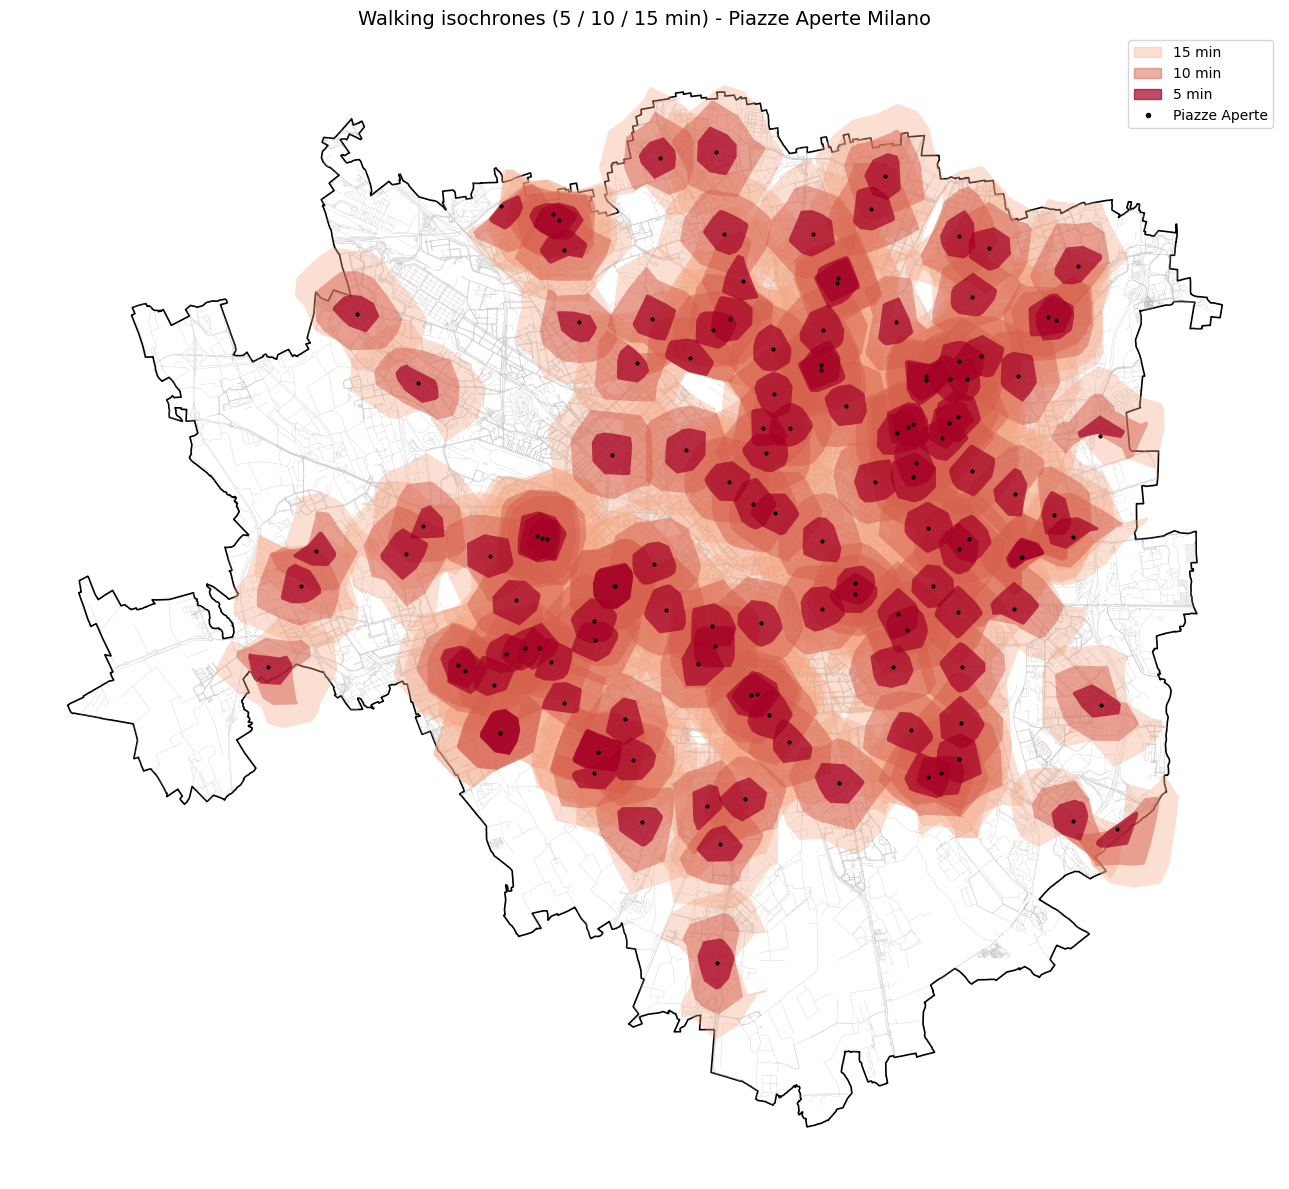

In [6]:
fig, ax = plt.subplots(figsize=(13, 13))

border.plot(ax=ax, linewidth=1.2, facecolor='none', edgecolor='black', zorder=1)
roads.plot(ax=ax, linewidth=0.15, color='#aaaaaa', zorder=2)

for t in [15, 10, 5]:
    color, alpha = COLOR_MAP[t]
    iso[t].plot(ax=ax, color=color, alpha=alpha, edgecolor='none', zorder=3)

points_piazze.plot(ax=ax, markersize=4, color='black', zorder=5)

patches = [mpatches.Patch(color=COLOR_MAP[t][0], alpha=COLOR_MAP[t][1], label=f'{t} min') for t in [15, 10, 5]]
ax.legend(
    handles=patches + [plt.Line2D([0],[0], marker='o', color='w',
                                   markerfacecolor='black', markersize=5, label='Piazze Aperte')],
    loc='upper right', fontsize=10
)
ax.set_title('Walking isochrones (5 / 10 / 15 min) - Piazze Aperte Milano', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/isochrone_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Spatial analysis

### 6a. Coverage - what % of Milan is within X min of a piazza?

In [7]:
milan_area = border.to_crs('EPSG:32632').area.sum()

for t in TRIP_TIMES:
    dissolved = iso[t].to_crs('EPSG:32632').union_all()
    covered   = dissolved.area
    pct       = covered / milan_area * 100
    print(f'{t} min  →  {covered/1e6:.2f} km²  ({pct:.1f}% of Milan)')

5 min  →  35.11 km²  (19.3% of Milan)
10 min  →  91.59 km²  (50.4% of Milan)
15 min  →  128.00 km²  (70.4% of Milan)


### 6b. Counts within each isochrone

In [8]:
def count_poi_in_isochrone(iso_gdf: gpd.GeoDataFrame, poi_gdf: gpd.GeoDataFrame, label: str) -> pd.Series:
    poi_pts = poi_gdf.copy()
    if not all(poi_pts.geometry.geom_type == 'Point'):
        poi_pts['geometry'] = poi_pts.geometry.centroid
    poi_pts = poi_pts[['geometry']].to_crs(iso_gdf.crs)
    joined = gpd.sjoin(poi_pts, iso_gdf[['piazza_id', 'geometry']], how='inner', predicate='within')
    return joined.groupby('piazza_id').size().rename(f'n_{label}')

summary = iso_10min[['piazza_id']].copy()
summary = summary.merge(count_poi_in_isochrone(iso_10min, shops,            'shops'),        on='piazza_id', how='left')
summary = summary.merge(count_poi_in_isochrone(iso_10min, education,        'education'),    on='piazza_id', how='left')
summary = summary.merge(count_poi_in_isochrone(iso_10min, healthcare,       'healthcare'),   on='piazza_id', how='left')
summary = summary.merge(count_poi_in_isochrone(iso_10min, transit_stations, 'transit'),      on='piazza_id', how='left')
summary = summary.merge(count_poi_in_isochrone(iso_10min, food_drink,       'food_drink'),   on='piazza_id', how='left')
summary = summary.merge(count_poi_in_isochrone(iso_10min, places_overture_all, 'places'),    on='piazza_id', how='left')
summary = summary.merge(count_poi_in_isochrone(iso_10min, green_areas,      'green_areas'),  on='piazza_id', how='left')
summary = summary.fillna(0).astype({c: int for c in summary.columns if c.startswith('n_')})
summary

C:\Users\genua\AppData\Local\Temp\ipykernel_7524\1116718175.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poi_pts['geometry'] = poi_pts.geometry.centroid
C:\Users\genua\AppData\Local\Temp\ipykernel_7524\1116718175.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  poi_pts['geometry'] = poi_pts.geometry.centroid


,piazza_id,n_shops,n_education,n_healthcare,n_transit,n_food_drink,n_places,n_green_areas
0,33,25,8,7,35,13,155,17
1,35,15,14,4,50,28,207,33
2,15,11,8,6,57,11,103,26
3,52,29,14,8,59,41,271,49
4,102,82,29,23,65,65,548,27
...,...,...,...,...,...,...,...,...
127,73,52,31,15,50,38,410,17
128,72,60,40,21,58,64,561,15
129,27,35,19,19,58,38,294,41
130,131,27,44,10,72,63,346,28


### 6c. Coverage by municipality

In [9]:
MUN_NAME_COL = 'MUNICIPIO'

mun_proj   = municipalities[[MUN_NAME_COL, 'geometry']].to_crs('EPSG:32632')
iso_5_proj = iso_5min.to_crs('EPSG:32632')

joined_mun = gpd.sjoin(iso_5_proj[['piazza_id', 'geometry']], mun_proj, how='left', predicate='intersects')
counts_mun = joined_mun.groupby(MUN_NAME_COL)['piazza_id'].nunique().rename('n_piazze').reset_index()
counts_mun = counts_mun.sort_values('n_piazze', ascending=False)
counts_mun

,MUNICIPIO,n_piazze
1,2,26
5,6,26
2,3,22
8,9,22
3,4,19
6,7,16
0,1,15
7,8,14
4,5,12


### 6d. Coverage by NIL

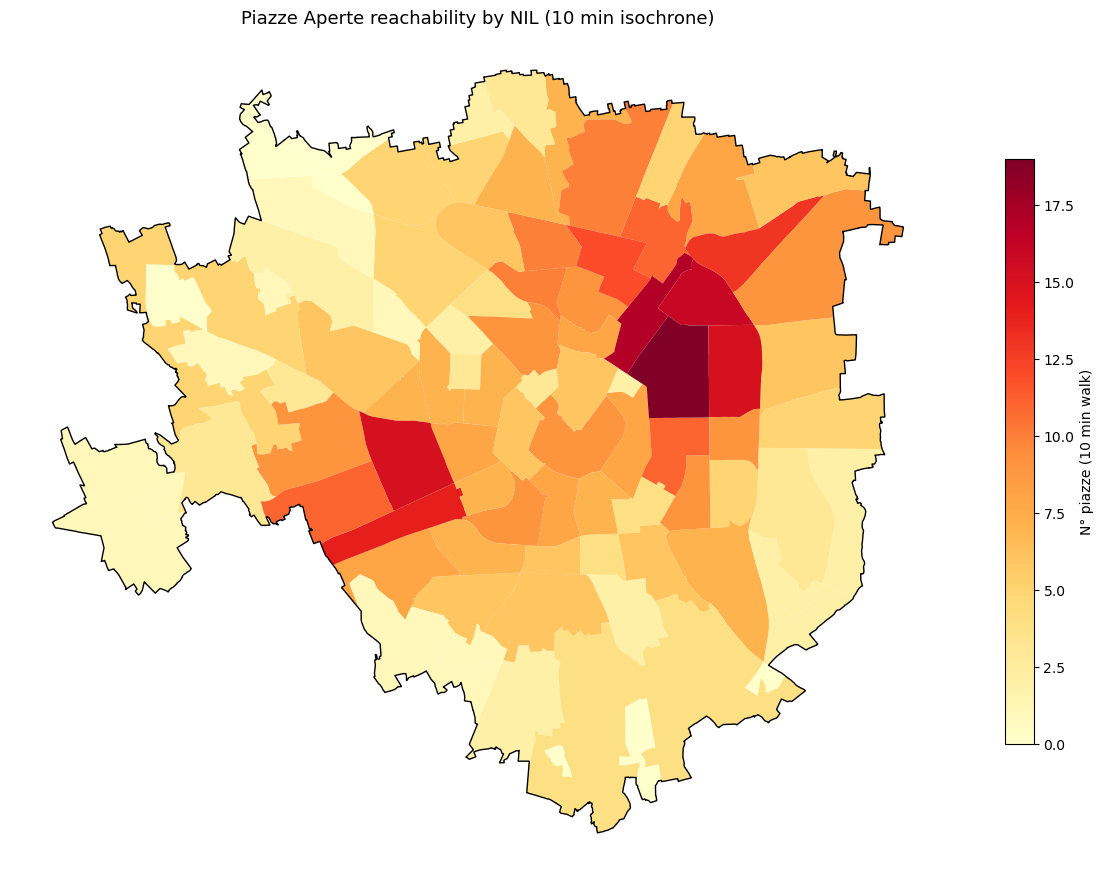

In [10]:
NIL_NAME_COL = 'NIL'

nil_proj    = nil[[NIL_NAME_COL, 'geometry']].to_crs('EPSG:32632')
iso_10_proj = iso_10min.to_crs('EPSG:32632')

joined_nil  = gpd.sjoin(iso_10_proj[['piazza_id', 'geometry']], nil_proj, how='left', predicate='intersects')
counts_nil  = joined_nil.groupby(NIL_NAME_COL)['piazza_id'].nunique().rename('n_piazze').reset_index()
counts_nil  = counts_nil.sort_values('n_piazze', ascending=False)

nil_map = nil.merge(counts_nil, on=NIL_NAME_COL, how='left').fillna(0)
fig, ax = plt.subplots(figsize=(12, 12))
nil_map.plot(column='n_piazze', ax=ax, legend=True, cmap='YlOrRd',
             legend_kwds={'label': 'N° piazze (10 min walk)', 'shrink': 0.5})
border.plot(ax=ax, linewidth=1, facecolor='none', edgecolor='black')
ax.set_title('Piazze Aperte reachability by NIL (10 min isochrone)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/nil_coverage_map.png', dpi=150, bbox_inches='tight')
plt.show()

### 6e. Comparison with population density

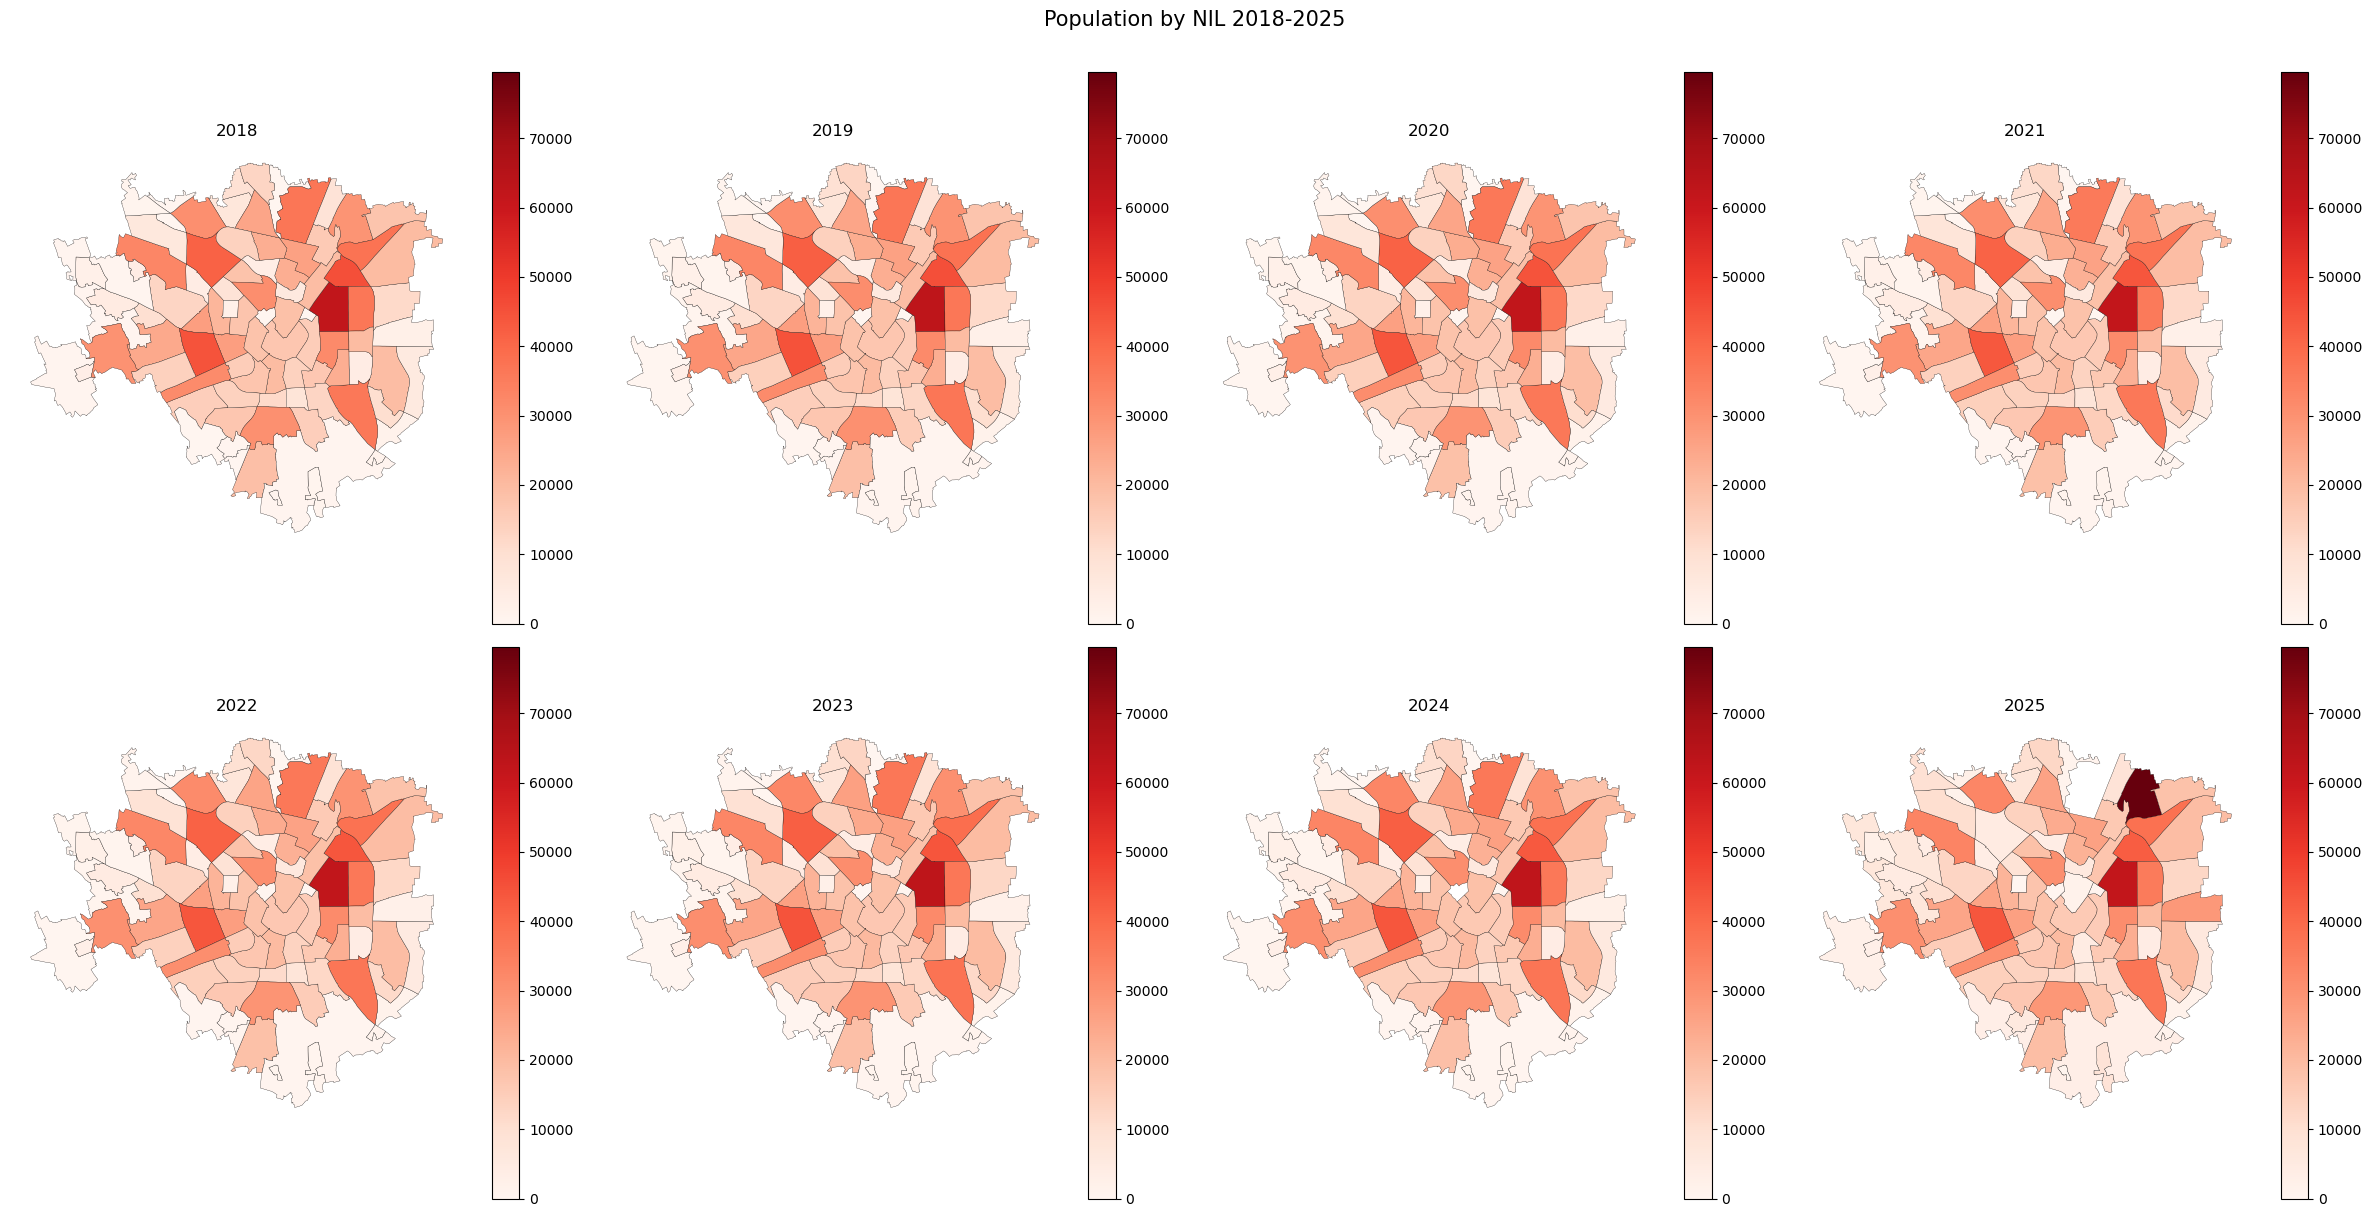

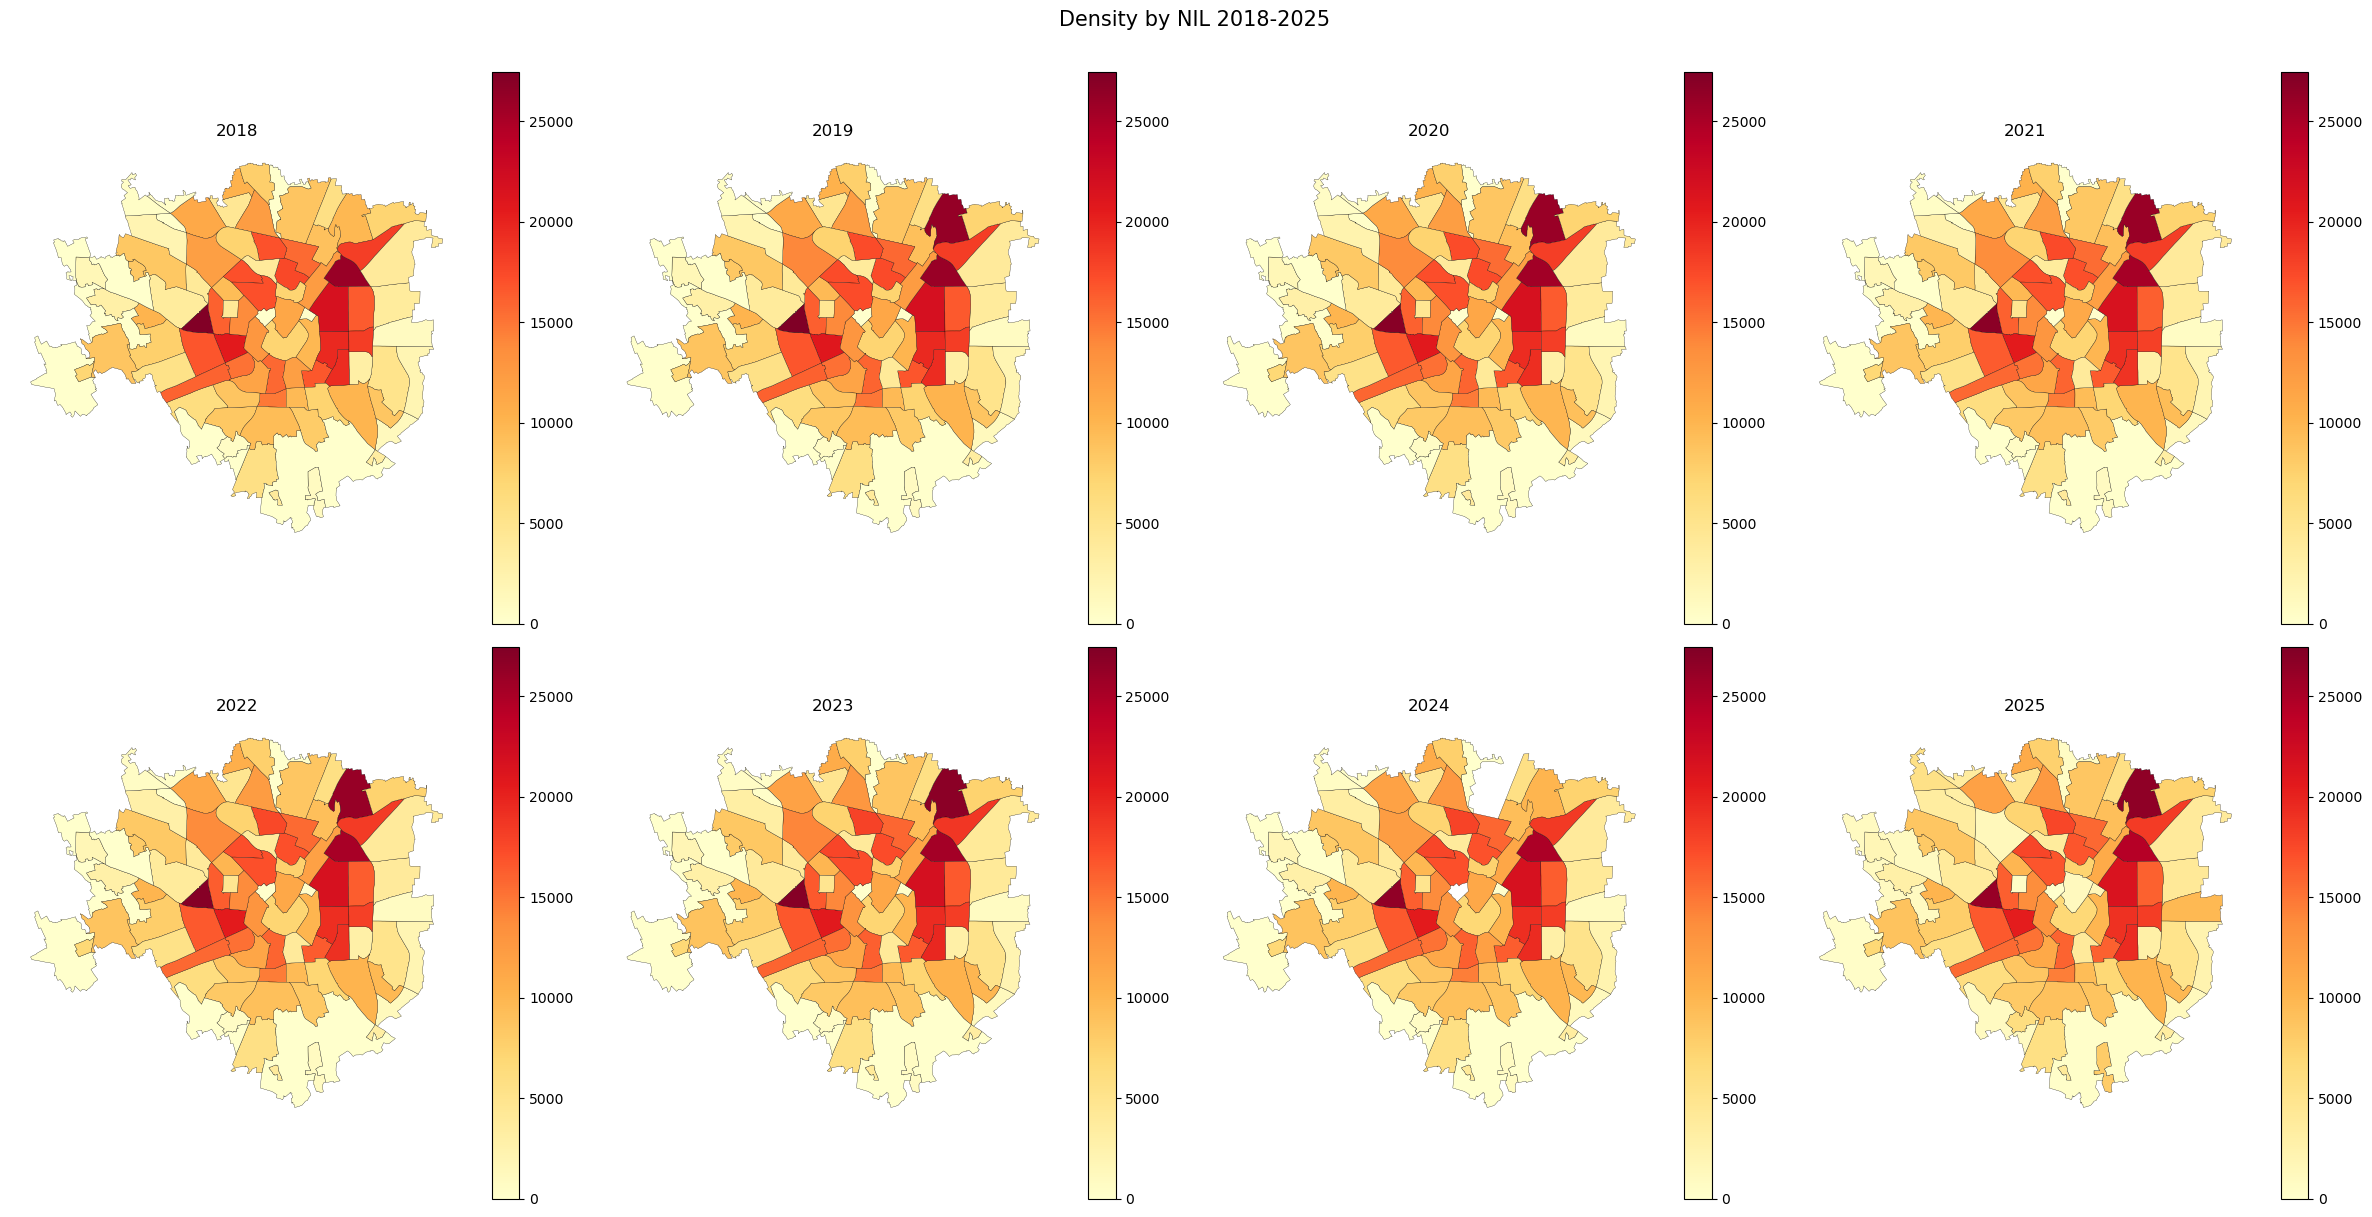

In [11]:
years = sorted(nil_full.loc[nil_full["Anno"] >= 2018, "Anno"].unique())

vmin_tot = nil_full.loc[nil_full["Anno"] >= 2018, "Totale"].min()
vmax_tot = nil_full.loc[nil_full["Anno"] >= 2018, "Totale"].max()

vmin_den = nil_full.loc[nil_full["Anno"] >= 2018, "densita (km quadrato)"].min()
vmax_den = nil_full.loc[nil_full["Anno"] >= 2018, "densita (km quadrato)"].max()

def plot_nil_years(nil_gdf, nil_full, years, col, vmin, vmax, title, cmap='Reds'):
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    axes = axes.flatten()
    for ax, year in zip(axes, years):
        df_year = nil_full[nil_full["Anno"] == year]
        gdf = nil_gdf.merge(df_year[["NIL", col]], left_on="ID_NIL", right_on="NIL", how="left")
        gdf.plot(column=col, cmap=cmap, vmin=vmin, vmax=vmax,
                 edgecolor="black", linewidth=0.2, legend=True, ax=ax)
        ax.set_title(str(year))
        ax.axis("off")
    plt.suptitle(title, fontsize=15, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/{title.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_nil_years(nil, nil_full, years, "Totale",  vmin_tot, vmax_tot, "Population by NIL 2018-2025")
plot_nil_years(nil, nil_full, years, "densita (km quadrato)", vmin_den, vmax_den, "Density by NIL 2018-2025", cmap="YlOrRd")